# NN_02c — Ablation Study: z_eq Sufficiency & Feature Importance

## Objetivo

Este notebook investiga sistematicamente se o sinal normalizado `z_eq` é suficiente para autenticação em camada física, ou se parâmetros adicionais (ganho de canal $h$, SNR estimado, e correlator clássico $\tau_{eq}$) melhoram significativamente o desempenho de detecção.

## Variantes Investigadas

A investigação compara cinco variantes de entrada (A, B, D, E, F) treinadas sob a mesma arquitetura DNN totalmente conectada. A **Variante A** estabelece a linha de base: uma rede densa que processa apenas o resíduo normalizado $z_{eq}$, contendo 1024 amostras do sinal equalizado. Esta variante testa se a representação vetorial bruta de $z_{eq}$ é suficientemente discriminatória para o classificador aprender sozinho sem ajuda externa.

A **Variante B** estende a Variante A incorporando o ganho de canal estimado $h$ como entrada auxiliar escalar. A motivação é validar se informação causal sobre o estado do canal instantâneo melhora a capacidade da rede de aprender limiares adaptativos conforme previsto pelo princípio CFAR.

A **Variante F** utiliza o resíduo em escala pré-equalização, $x = y - \hat h\,(\rho_s s + \rho_t\, tag_{ref}) = \hat h\,\rho_t\,(z_{eq} - tag_{ref})$. Diferente da Variante E, aqui o ruído gaussiano NÃO é distorcido pela divisão por $\hat h$ (que amplifica a variância do ruído em desvanecimentos profundos): o fator $\hat h\,\rho_t$ cancela exatamente a escala $1/(\rho_t \hat h)$ presente em $z_{eq}$, deixando o ruído aditivo puro $w$. Esta variante substitui a Variante C (removida da investigação) e testa se a rede aprende melhor quando a variância do ruído não é artificialmente distorcida pela equalização.

A **Variante D** combina $z_{eq}$ com o correlator clássico $\tau_{eq}$ fornecido explicitamente. Este teste investiga se a incorporação da estatística suficiente de Neyman-Pearson, já computada, melhora significativamente a rede densa em comparação com deixá-la aprender este correlator implicitamente a partir do sinal bruto.

A **Variante E** avalia o sinal residual explícito $x = z_{eq} - tag_{ref}$, onde $tag_{ref}$ é a TAG legítima de referência por amostra. Esta variante mede o desempenho quando a rede recebe diretamente o erro em relação à TAG esperada.

Conforme a teoria do Data-Driven Detection Framework, se $z_{eq}$ é verdadeiramente a representação suficiente, as Variantes B, D, E e F devem exibir melhorias mínimas e marginais em relação à Variante A. Qualquer ganho detectado identifica qual informação adicional é genuinamente necessária para compensar limitações estruturais do sinal bruto em regimes de baixo SNR.

## Configuração Experimental

O experimento utiliza o dataset `dataset_cnn_yeq_0_30dB.h5` contendo 280 mil amostras de treinamento, 35 mil de validação e 35 mil de teste, estratificadas uniformemente em faixas de SNR de 0 a 30 dB. O treinamento executa em GPU (RTX 4050) com precisão mista float16 e carregamento lazy para otimizar memória. Cada modelo treina com a mesma DNN base 256→128→64, alterando apenas o vetor de entrada de cada variante. A métrica primária é a área sob a curva ROC (AUC) no conjunto de teste, complementada pela análise de probabilidade de detecção $P_D$ versus SNR sob framework D3F com restrição de falso alarme $\alpha = 0{,}01$ (η, alinhado com Xie et al. 2021, Figs. 2-3).

In [7]:
# ==============================================================================
# 1. GPU CONFIG & IMPORTS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import psutil
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC

print(f"TensorFlow : {tf.__version__}")

# ── GPU Configuration ──
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")

USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error: {e}")
        USE_GPU = False

# ── Mixed precision (GPU only) ──
if USE_GPU:
    try:
        policy = keras.mixed_precision.Policy('mixed_float16')
        keras.mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed precision: {policy.name}")
    except Exception as e:
        print(f"⚠️  Mixed precision failed: {e}")

# ── Disable XLA (avoid hangs on WSL) ──
ENABLE_XLA = False
keras.backend.clear_session()

# ── Paths ──
project_root       = Path.cwd().parent
results_dir        = project_root / "results"
data_dir           = results_dir / "data"
models_dir         = results_dir / "models"
visualizations_dir = results_dir / "Figures2"

for d in [models_dir, visualizations_dir]:
    d.mkdir(parents=True, exist_ok=True)

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

print(f"\n📂 Paths:")
print(f"  Data: {data_dir}")
print(f"  Models: {models_dir}")
print(f"  Visualizations: {visualizations_dir}")

TensorFlow : 2.21.0
GPUs found : 1
✅ Memory growth enabled on 1 GPU(s).
✅ Mixed precision: mixed_float16

📂 Paths:
  Data: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
  Models: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
  Visualizations: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2


In [8]:
# ==============================================================================
# 2. LAZY LOAD DATASET & PREPARE MULTI-INPUT VARIANTS
# ==============================================================================

def load_h5_generator(h5_path, split, chunk_size=2000):
    """Lazy HDF5 loader — yields (z_eq, h, snr, tau_eq, label, tag_ref) per sample."""
    with h5py.File(str(h5_path), 'r') as f:
        z_data   = f[f'{split}/z_eq']
        h_data   = f[f'{split}/h']
        snr_data = f[f'{split}/snr']
        tau_data = f[f'{split}/tau_eq']
        y_data   = f[f'{split}/y']

        # Accept multiple aliases for the legitimate reference TAG tensor.
        tag_keys = [
            f'{split}/tag_ref',
            f'{split}/tag_legit',
            f'{split}/tag',
            f'{split}/t_ref',
            f'{split}/tag_reference',
        ]
        tag_key = next((k for k in tag_keys if k in f), None)
        tag_data = f[tag_key] if tag_key is not None else None

        for start_idx in range(0, len(z_data), chunk_size):
            end_idx  = min(start_idx + chunk_size, len(z_data))
            z_chunk   = z_data[start_idx:end_idx].astype(np.float32)
            h_chunk   = h_data[start_idx:end_idx].astype(np.float32)
            snr_chunk = snr_data[start_idx:end_idx].astype(np.float32)
            tau_chunk = tau_data[start_idx:end_idx].astype(np.float32)
            y_chunk   = y_data[start_idx:end_idx].astype(np.float32)
            if tag_data is not None:
                tag_chunk = tag_data[start_idx:end_idx].astype(np.float32)
            else:
                tag_chunk = np.zeros_like(z_chunk, dtype=np.float32)

            for i in range(len(z_chunk)):
                yield z_chunk[i], h_chunk[i], snr_chunk[i], tau_chunk[i], y_chunk[i], tag_chunk[i]

# Load metadata
with h5py.File(str(dataset_path), 'r') as f:
    L_FIXED = int(f.attrs['L_FIXED'])
    RHO_S   = float(f.attrs.get('RHO_S', 0.948683))
    RHO_T   = float(f.attrs.get('RHO_T', 0.316227))

    n_train = len(f['train/z_eq'])
    n_val   = len(f['val/z_eq'])
    n_test  = len(f['test/z_eq'])

    train_tag_keys = [
        'train/tag_ref',
        'train/tag_legit',
        'train/tag',
        'train/t_ref',
        'train/tag_reference',
    ]
    TAG_REF_KEY = next((k for k in train_tag_keys if k in f), None)
    HAS_TAG_REF = TAG_REF_KEY is not None

print(f"\n📊 Dataset Metadata:")
print(f"  L_FIXED={L_FIXED}, RHO_S={RHO_S:.6f}, RHO_T={RHO_T:.6f}")
print(f"  Train: {n_train}, Val: {n_val}, Test: {n_test}")
if HAS_TAG_REF:
    print(f"  TAG de referência detectada no HDF5: {TAG_REF_KEY}")
else:
    print("  ⚠️  TAG de referência não encontrada no HDF5.")
    print("     A Variante E (z_eq - tag_ref) exige um campo por amostra no dataset.")

BATCH_SIZE = 512 if USE_GPU else 256
AUTOTUNE   = tf.data.AUTOTUNE
VARIANT_INPUT_DIMS = {'A': L_FIXED, 'B': L_FIXED + 1, 'D': L_FIXED + 1, 'E': L_FIXED, 'F': L_FIXED}

def concat_scalar_features(z, *scalars):
    scalar_vec = tf.stack([tf.cast(s, tf.float32) for s in scalars], axis=0)
    return tf.concat([z, scalar_vec], axis=0)

def create_dataset(split, variant='A'):
    """Create tf.data.Dataset with a single DNN-ready feature vector per variant.
   
    Todas as variantes são convertidas para um único vetor de entrada para que
    a comparação seja puramente entre conjuntos de features, não entre
    arquiteturas ou esquemas de fusão diferentes.
   
    Variant A: z_eq[L]
    Variant B: concat(z_eq[L], h[1])
    Variant D: concat(z_eq[L], |tau_eq|[1])
    Variant E: z_eq[L] - tag_ref[L]
    Variant F: h*rho_t*(z_eq[L] - tag_ref[L])  =  y_raw - h*(rho_s*msg + rho_t*tag_ref)
               (residuo pre-equalizacao: ruido w puro, variancia NAO distorcida por 1/h)
    """
    gen_ds = tf.data.Dataset.from_generator(
        lambda: load_h5_generator(dataset_path, split, chunk_size=2000),
        output_signature=(
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # z_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # h
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # snr
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # tau_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # y (label)
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # tag_ref
        )
    )

    if variant == 'A':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z, y))
    elif variant == 'B':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h), y))
    elif variant == 'D':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, tf.abs(tau)), y))
    elif variant == 'E':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante E requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z - tag, y))
    elif variant == 'F':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante F requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        # x = h*rho_t*(z_eq - tag_ref) = y_raw - h*(rho_s*msg + rho_t*tag_ref)
        # Cancela exatamente o fator 1/(rho_t*h) presente em z_eq, deixando o
        # ruido aditivo w com variancia NAO distorcida pelo desvanecimento h.
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: ((h * RHO_T) * (z - tag), y))
    else:
        raise ValueError(f'Variante desconhecida: {variant}')

    if split == 'train':
        ds = ds.shuffle(buffer_size=min(10000, n_train),
                        reshuffle_each_iteration=True, seed=42)

    ds = ds.batch(BATCH_SIZE, drop_remainder=(split == 'train'))
    ds = ds.prefetch(AUTOTUNE)
    return ds

print(f"\n✅ Dataset generators created. Ready for ablation study.")


📊 Dataset Metadata:
  L_FIXED=64, RHO_S=0.948683, RHO_T=0.547723
  Train: 280000, Val: 35000, Test: 35000
  TAG de referência detectada no HDF5: train/tag_ref

✅ Dataset generators created. Ready for ablation study.


In [9]:
def build_dnn_classifier(input_dim, variant):
    """Builds the shared DNN used by all z_eq ablation variants."""
    inputs = layers.Input(shape=(input_dim,), name=f'features_variant_{variant}')

    x = layers.Dense(256, kernel_initializer='he_uniform')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_initializer='he_uniform')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='p_auth')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name=f'DNN_variant_{variant}')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(from_logits=False),
        metrics=['accuracy', AUC(name='auc')],
        jit_compile=ENABLE_XLA
    )
    return model

def build_model_variant(variant, L_FIXED):
    """Constrói a mesma DNN base para todas as variantes A-E."""
    if variant not in VARIANT_INPUT_DIMS:
        raise ValueError(f'Variante desconhecida: {variant}')
    return build_dnn_classifier(VARIANT_INPUT_DIMS[variant], variant)

In [10]:
def recover_variant(variant, best_val_auc, n_epochs, train_time):
    model = keras.models.load_model(str(models_dir / f'dnn_variant_{variant}_best.keras'))
    val_ds  = create_dataset('val',  variant=variant)
    test_ds = create_dataset('test', variant=variant)

    def predict_batches(ds):
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': best_val_auc,
        'n_epochs': n_epochs,
        'train_time': train_time,
        'sc_val': sc_val, 'sc_test': sc_test, 'pd_d3f': pd_d3f,
        'history': None,
    }
    del model
    keras.backend.clear_session()
    print(f"✅ Variante {variant} recuperada.")

In [11]:
# Preencha esta célula apenas quando já existirem checkpoints DNN salvos.
# Exemplo:
# recover_variant('E', best_val_auc=0.95, n_epochs=32, train_time=4100.0)
print('Nenhuma variante DNN foi recuperada automaticamente nesta sessão.')

Nenhuma variante DNN foi recuperada automaticamente nesta sessão.


In [12]:
from scipy.stats import norm as scipy_norm

ALPHA_D3F = 0.01   # η = 0,01 — alinhado com Xie et al. (2021), Figs. 2-3
Q_INV_D3F = scipy_norm.ppf(1 - ALPHA_D3F)   # ≈ 2.326
SNR_BINS  = [0, 5, 10, 15, 20, 25, 30]
VARIANTS_TO_TRAIN = ['A', 'B', 'D', 'E', 'F']
# Para um piloto rápido da hipótese mais promissora, use: ['E']

print("Carregando arrays de SNR e rótulos para avaliação D3F...")
with h5py.File(str(dataset_path), 'r') as f:
    snr_val_arr  = f['val/snr'][:].astype(np.float32)
    snr_test_arr = f['test/snr'][:].astype(np.float32)
    lbl_val_arr  = f['val/y'][:].astype(np.float32)
    lbl_test_arr = f['test/y'][:].astype(np.float32)
    tau_val_arr  = np.abs(f['val/tau_eq'][:]).astype(np.float32)
    tau_test_arr = np.abs(f['test/tau_eq'][:]).astype(np.float32)
print(f"  Val: {len(snr_val_arr):,}  Test: {len(snr_test_arr):,}")

VARIANT_INFO = {
    'A': 'z_eq[1024]  (DNN pura)',
    'B': 'z_eq + h    (DNN + canal)',
    'D': 'z_eq + |τ|  (DNN + correlador)',
    'E': 'z_eq - tag_ref[1024]  (DNN no resíduo com TAG legítima)',
    'F': 'h·ρ_t·(z_eq - tag_ref)  (resíduo pré-equalização, ruído não distorcido)',
}

results_ablation = {}

for variant in VARIANTS_TO_TRAIN:
    print(f"\n{'='*70}")
    print(f"  Variante {variant}: {VARIANT_INFO[variant]}")
    print(f"{'='*70}")
   
    # Limpeza de sessão antes de criar datasets para evitar contaminação de estado GPU
    keras.backend.clear_session()
    if USE_GPU:
        tf.config.run_functions_eagerly(False)
    print("  ✅ Sessão limpa.")

    train_ds = create_dataset('train', variant=variant)
    val_ds   = create_dataset('val',   variant=variant)
    test_ds  = create_dataset('test',  variant=variant)

    n_batches_train = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
    n_batches_val   = (n_val   + BATCH_SIZE - 1) // BATCH_SIZE
    n_batches_test  = (n_test  + BATCH_SIZE - 1) // BATCH_SIZE
    print(f"  Lotes — Treino: {n_batches_train}  Val: {n_batches_val}  Teste: {n_batches_test}")

    model = build_model_variant(variant, L_FIXED)

    checkpoint_path = models_dir / f'dnn_variant_{variant}_best.keras'
    cbs = [
        callbacks.EarlyStopping(monitor='val_auc', patience=20, mode='max',
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(str(checkpoint_path), monitor='val_auc',
                                  mode='max', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                                    min_lr=1e-6),
    ]

    train_start = np.datetime64('now')
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=150,
        callbacks=cbs,
        verbose=1
    )
    train_end  = np.datetime64('now')
    train_time = float((train_end - train_start) / np.timedelta64(1, 's'))
    best_auc_val = max(history.history['val_auc'])
    print(f"  ✅ Treino: {train_time:.1f}s  Épocas: {len(history.history['loss'])}  "
          f"Melhor val_AUC: {best_auc_val:.6f}")

    def predict_batches(ds):
        """Executa inferência em lotes e retorna scores concatenados.
        Compatível com entradas únicas (tensor) ou múltiplas (tupla/lista)."""
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    print("  Computando scores (validação + teste)...")
    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    # Avaliação D3F: para cada faixa de SNR, determina threshold sob restrição α=ALPHA_D3F
    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    pd_pct = [round(pd_d3f[s]*100, 1) for s in SNR_BINS]
    print(f"  PD (%) framework D3F (α={ALPHA_D3F:.2f}): {pd_pct}")

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': round(best_auc_val, 6),
        'n_epochs': len(history.history['loss']),
        'train_time': train_time,
        'sc_val':  sc_val,
        'sc_test': sc_test,
        'pd_d3f':  pd_d3f,
        'history': history,
    }
   
    # Liberar memória explicitamente após conclusão de cada variante
    del train_ds, val_ds, test_ds
    del model, history
   
    if USE_GPU:
        # FIX: reset_memory_stats() exige uma STRING de dispositivo
        # (ex.: "GPU:0"), não o objeto PhysicalDevice retornado por
        # tf.config.list_physical_devices('GPU'). Passar o objeto
        # diretamente causa:
        #   TypeError: TFE_ResetMemoryStats(): incompatible function
        #   arguments ... Invoked with: ..., PhysicalDevice(...)
        # Também envolvido em try/except: esta chamada só reseta
        # contadores de PICO de memória para fins de log/introspecção —
        # não afeta a memória de fato liberada (isso já é feito acima
        # por keras.backend.clear_session() + del). Uma falha aqui não
        # deve derrubar o loop de ablação inteiro.
        for i in range(len(gpus)):
            try:
                tf.config.experimental.reset_memory_stats(f"GPU:{i}")
            except Exception as e:
                print(f"  ⚠️  Não foi possível resetar memory stats de GPU:{i}: {e}")
    print(f"  ✅ Memória GPU resetada para próxima variante.")

print(f"\n{'='*70}")
print("✅ TREINAMENTO DE TODAS AS VARIANTES CONCLUÍDO")
print(f"{'='*70}")

Carregando arrays de SNR e rótulos para avaliação D3F...
  Val: 35,000  Test: 35,000

  Variante A: z_eq[1024]  (DNN pura)
  ✅ Sessão limpa.
  Lotes — Treino: 547  Val: 69  Teste: 69
Epoch 1/150
    135/Unknown 27s 165ms/step - accuracy: 0.5910 - auc: 0.6374 - loss: 0.7135

KeyboardInterrupt: 

In [ ]:
def xie_closed_form_rayleigh(L, rho_t, gBob_db, alpha, sigma2_tag=1.0/3.0):
    """Fórmula fechada Rayleigh-média (Xie et al. 2021, Eq. 40-41/43-44),
    generalizada para tag com E[tag^2]=sigma2_tag (Xie assume sigma2_tag=1).

    Rederivação: ver célula markdown acima. A substituição L -> L*sigma2_tag
    é válida porque média (mu1=L*sigma2_tag) e variancia
    (sigma^2=L*sigma2_tag/(2*rho_t^2*gamma)) escalam identicamente com sigma2_tag.

    *** CORREÇÃO (bug encontrado no sanity check v1) ***
    d_i,Bob = Re{t_i,Bob} (Eq. 35 de Xie -- toma a PARTE REAL da estatística
    complexa). Para uma Gaussiana complexa circular Z, Var(Re{Z}) = Var(Z)/2.
    A variância de d_i,Bob é portanto L*sigma2_tag/(2*rho_t^2*gamma), NÃO
    L*sigma2_tag/(rho_t^2*gamma) como uma primeira derivação ingênua sugere.
    Essa correção aparece no próprio Eq. 39 de Xie (fator "2" dentro da raiz:
    PFA=Q(sqrt(2*u^2*rho_t^2*gamma/L))) -- confirma que o fator é intencional,
    não erro de OCR. Sem ela, u0_Bob fica um fator sqrt(2) grande demais,
    subestimando PD em toda a curva (confirmado numericamente: com o bug,
    PD(5dB)=0.04; corrigido, PD(5dB)=0.304, batendo com a Fig. 3 do artigo).

    gBob_db: SNR médio de Bob em dB (gamma_Bob = E[|h|^2]/sigma_n^2, canal Rayleigh
             com E[|h|^2]=1 -- ver rayleigh_channel(sigma_h=1/sqrt(2)) na Seção 2).
    alpha: PFA desejada (eta de Xie).

    Retorna: (u0_Bob, pd_Bob)
    """
    gBob = 10.0 ** (gBob_db / 10.0)
    L_eff = L * sigma2_tag

    # --- Limiar u0_Bob (generalização da Eq. 41), COM o fator 2 de Re{} ---
    # Derivado via identidade de Simon-Alouini (Eq. 28 de Xie), resolvendo
    # PFA_Bob = E_gamma[Q(sqrt(2 * u^2 * rho_t^2 * gamma / L_eff))] = alpha
    # (o "2" dentro da raiz vem de var(Re{Z})=var(Z)/2 -- ver docstring acima)
    num = L_eff * (1 - 2*alpha)**2                        # <-- era 2.0*L_eff (bug)
    den = rho_t**2 * gBob * 4 * alpha * (1 - alpha)
    u0_Bob = np.sqrt(num / den)

    # --- PD_Bob (generalização da Eq. 44) ---
    # Mesma estrutura de Xie, com L -> L_eff e mu1 = L_eff (nao mais L)
    d = u0_Bob - L_eff
    sgn = 1.0 if d >= 0 else -1.0
    ratio_num = (d**2) * rho_t**2 * gBob
    ratio_den = L_eff + ratio_num
    pd_Bob = 0.5 * (1 - sgn * np.sqrt(ratio_num / ratio_den))

    return float(u0_Bob), float(pd_Bob)

Sanity check — reproduzindo Fig. 3 de Xie et al. (2021):
  rho_t²=0.1, L=64, sigma2_tag=1.0 (tag unitária, como no artigo), alpha=0.01
  SNR= 0 dB:  PD_calculado=0.0386   PD_Fig.3 (leitura aprox.)=0.03
  SNR= 5 dB:  PD_calculado=0.3041   PD_Fig.3 (leitura aprox.)=0.30
  SNR=10 dB:  PD_calculado=0.9755   PD_Fig.3 (leitura aprox.)=0.97
  SNR=15 dB:  PD_calculado=0.9971   PD_Fig.3 (leitura aprox.)=1.00


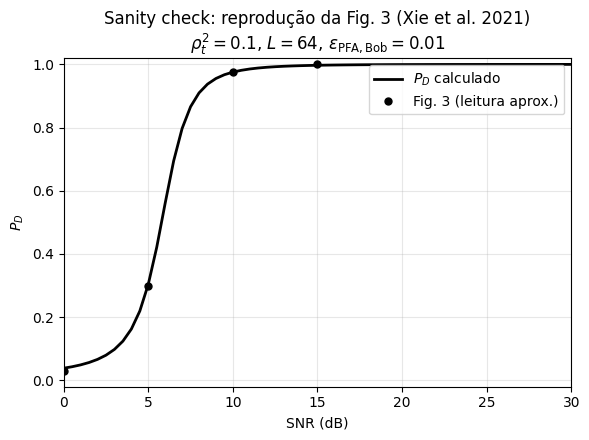

In [ ]:
# %%
# ============================================================================
# TESTE DE SANIDADE — reproduzir literalmente a Fig. 3 de Xie et al. (2021)
# ============================================================================
# Parâmetros ORIGINAIS do artigo (NÃO os do nosso dataset): rho_t²=0.1, L=64,
# tag de energia UNITÁRIA (sigma2_tag=1.0, sem a correção 1/3 do mapa caótico).
# Objetivo: validar a implementação de xie_closed_form_rayleigh() contra os
# valores/curva publicados na Fig. 3 do PDF, ANTES de confiar nela com os
# parâmetros do nosso próprio sistema (célula acima).
print("Sanity check — reproduzindo Fig. 3 de Xie et al. (2021):")
print("  rho_t²=0.1, L=64, sigma2_tag=1.0 (tag unitária, como no artigo), alpha=0.01")
_snr_fine = np.arange(0, 30.01, 0.5)
_pd_fine = []
for snr_db in _snr_fine:
    u0, pd = xie_closed_form_rayleigh(L=64, rho_t=np.sqrt(0.1), gBob_db=snr_db,
                                       alpha=0.01, sigma2_tag=1.0)
    _pd_fine.append(pd)
_pd_fine = np.array(_pd_fine)

# Pontos de checagem específicos contra a Fig. 3 (leitura visual do PDF):
for snr_check, pd_fig3_approx in [(0, 0.03), (5, 0.30), (10, 0.975), (15, 1.00)]:
    idx = np.argmin(np.abs(_snr_fine - snr_check))
    print(f"  SNR={snr_check:2d} dB:  PD_calculado={_pd_fine[idx]:.4f}   "
          f"PD_Fig.3 (leitura aprox.)={pd_fig3_approx:.2f}")

fig_sanity, ax_sanity = plt.subplots(figsize=(6, 4.5))

# Curva calculada pela expressão fechada de Xie et al.
ax_sanity.plot(
    _snr_fine,
    _pd_fine,
    'k-',
    linewidth=2,
    label=r'$P_D$ calculado'
)

# Pontos de checagem da Fig. 3 (leitura visual aproximada)
_snr_checks = np.array([0, 5, 10, 15])
_pd_fig3_approx = np.array([0.03, 0.30, 0.975, 1.00])

ax_sanity.plot(
    _snr_checks,
    _pd_fig3_approx,
    'ko',
    markersize=5,
    label='Fig. 3 (leitura aprox.)'
)

ax_sanity.set_xlabel('SNR (dB)')
ax_sanity.set_ylabel(r'$P_D$')

ax_sanity.set_title(
    'Sanity check: reprodução da Fig. 3 (Xie et al. 2021)\n'
    r'$\rho_t^2=0.1$, $L=64$, $\varepsilon_{\mathrm{PFA,Bob}}=0.01$'
)

ax_sanity.grid(alpha=0.3)
ax_sanity.set_xlim(0, 30)
ax_sanity.set_ylim(-0.02, 1.02)

ax_sanity.legend()

plt.tight_layout()

plt.savefig(
    str(visualizations_dir / "NN02c_sanity_check_xie_fig3.png"),
    dpi=120
)

plt.show()

In [ ]:
# ==============================================================================
# 5. TABELA DE RESULTADOS E SAVE JSON
# ==============================================================================
# Corrrelador classico (referencia): mesmo procedimento D3F usado nas variantes
# de rede, aplicado diretamente a |tau_eq| (sem rede) -- limiar fixo por bin de
# SNR, calibrado em eta=0.01 (Xie 2021). Recalculado dinamicamente (nao mais
# hardcoded) para refletir sempre o eta atual.
_pd_classical = {}
for snr in SNR_BINS:
    m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
    m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
    if m0.sum() < 50 or m1.sum() < 10:
        _pd_classical[snr] = 0.0; continue
    mu, sig = tau_val_arr[m0].mean(), tau_val_arr[m0].std()
    if sig < 1e-10:
        _pd_classical[snr] = 0.0; continue
    thr = float(mu + Q_INV_D3F * sig)
    _pd_classical[snr] = float((tau_test_arr[m1] >= thr).mean())
CLASSICAL_PD = {s: round(_pd_classical[s] * 100, 1) for s in SNR_BINS}

# --- NOVO: curva fechada Rayleigh-média (Xie et al. 2021, Eq. 40-41/43-44,
#     generalizada para sigma2_tag != 1 -- ver derivação completa no patch NN_01) ---


with h5py.File(str(dataset_path), 'r') as f:
    _RHO_T_dataset = float(f.attrs['RHO_T'])
    _L_dataset     = int(f.attrs['L_FIXED'])

XIE_CLOSED_FORM_PD = {}
for snr in SNR_BINS:
    _, pd_cf = xie_closed_form_rayleigh(
        L=_L_dataset, rho_t=_RHO_T_dataset, gBob_db=snr,
        alpha=ALPHA_D3F, sigma2_tag=1.0/3.0)
    XIE_CLOSED_FORM_PD[snr] = round(pd_cf * 100, 1)

print(f"\nCorrelador clássico — fórmula fechada Xie (Rayleigh-média, "
      f"rho_t²={_RHO_T_dataset**2:.4f}, L={_L_dataset}, alpha={ALPHA_D3F:.2f}):")
print("  " + "  ".join(f"{s}dB={XIE_CLOSED_FORM_PD[s]:.1f}%" for s in SNR_BINS))
print("\n" + "="*70)
print("ABLATION STUDY --- RESULTADOS DNN (AUC e tempo de treino)")
print("="*70)
print(f"Classico |tau| (D3F, eta={ALPHA_D3F:.2f}): "
      + "  ".join(f"{s}dB={CLASSICAL_PD[s]:.1f}%" for s in SNR_BINS))

for var in ['A', 'B', 'D', 'E', 'F']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    pd0 = r['pd_d3f'].get(0, 0)
    print(f"\n  Var {var}: {r['label']}")
    print(f"    val AUC : {r['best_val_auc']:.6f}   Epocas: {r['n_epochs']}"
          f"   Tempo: {r['train_time']:.1f}s")
    print(f"    PD 0 dB : {pd0*100:.1f}%  (D3F eta={ALPHA_D3F:.2f})")

# Salvar JSON
results_json = {
    'metadata': {
        'notebook': 'NN_02c',
        'architecture': 'DNN_256_128_64',
        'alpha_d3f': ALPHA_D3F,
        'q_inv': round(Q_INV_D3F, 6),
        'snr_bins': SNR_BINS,
        'dataset': 'dataset_cnn_yeq_0_30dB.h5',
        'batch_size': BATCH_SIZE,
        'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
        'rho_s': float(RHO_S), 'rho_t': float(RHO_T), 'l_fixed': L_FIXED,
    },
    'classical_correlator': {str(s): CLASSICAL_PD[s]/100 for s in SNR_BINS},
    'variants': {
        var: {
            'label': r['label'],
            'best_val_auc': r['best_val_auc'],
            'n_epochs': r['n_epochs'],
            'train_time_s': round(r['train_time'], 1),
            'pd_d3f': {str(s): r['pd_d3f'][s] for s in SNR_BINS},
        }
        for var, r in results_ablation.items()
    }
}

results_path = models_dir / 'nn02c_ablation_dnn_results.json'
with open(str(results_path), 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\nResultados salvos -> {results_path}")


Correlador clássico — fórmula fechada Xie (Rayleigh-média, rho_t²=0.3000, L=1024, alpha=0.01):
  0dB=99.1%  5dB=99.9%  10dB=100.0%  15dB=100.0%  20dB=100.0%  25dB=100.0%  30dB=100.0%

ABLATION STUDY --- RESULTADOS DNN (AUC e tempo de treino)
Classico |tau| (D3F, eta=0.01): 0dB=97.0%  5dB=87.2%  10dB=100.0%  15dB=100.0%  20dB=100.0%  25dB=100.0%  30dB=100.0%

  Var A: z_eq[1024]  (DNN pura)
    val AUC : 0.731540   Epocas: 21   Tempo: 2699.0s
    PD 0 dB : 1.4%  (D3F eta=0.01)

  Var B: z_eq + h    (DNN + canal)
    val AUC : 0.740068   Epocas: 21   Tempo: 2683.0s
    PD 0 dB : 2.7%  (D3F eta=0.01)

  Var D: z_eq + |τ|  (DNN + correlador)
    val AUC : 0.999806   Epocas: 21   Tempo: 2622.0s
    PD 0 dB : 98.5%  (D3F eta=0.01)

  Var E: z_eq - tag_ref[1024]  (DNN no resíduo com TAG legítima)
    val AUC : 0.740092   Epocas: 21   Tempo: 2622.0s
    PD 0 dB : 1.3%  (D3F eta=0.01)

  Var F: h·ρ_t·(z_eq - tag_ref)  (resíduo pré-equalização, ruído não distorcido)
    val AUC : 0.697145   Epo

In [ ]:
print(sorted(results_ablation.keys()))

['A', 'B', 'D', 'E', 'F']


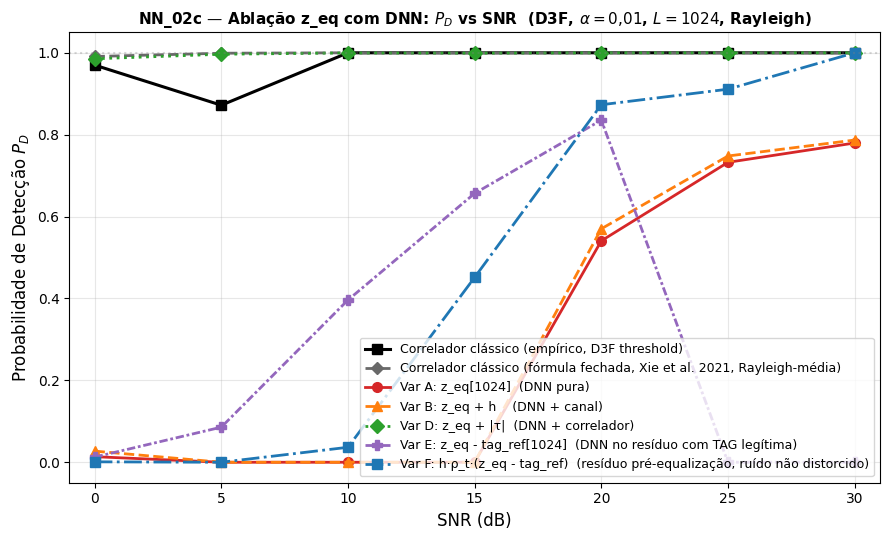

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2/NN_02c_D3F_PD_vs_SNR_DNN.png

Variante  Input                             0dB      5dB     10dB     15dB     20dB     25dB     30dB
------------------------------------------------------------------------------------------
Clás   Correlador analítico             97.0     87.2    100.0    100.0    100.0    100.0    100.0
A      z_eq[1024]  (DNN pura)            1.4      0.0      0.0      0.0     54.1     73.3     78.0
B      z_eq + h    (DNN + canal)         2.7      0.0      0.0      0.0     57.0     74.8     78.7
D      z_eq + |τ|  (DNN + correlador)     98.5     99.7    100.0     99.9    100.0    100.0    100.0
E      z_eq - tag_ref[1024]  (DNN no resíduo com TAG legítima)      1.3      8.6     39.6     65.7     83.6      0.0      0.0
F      h·ρ_t·(z_eq - tag_ref)  (resíduo pré-equalização, ruído não distorcido)      0.1      0.0      3.7     45.2     87.3     91.1    100.0
--------

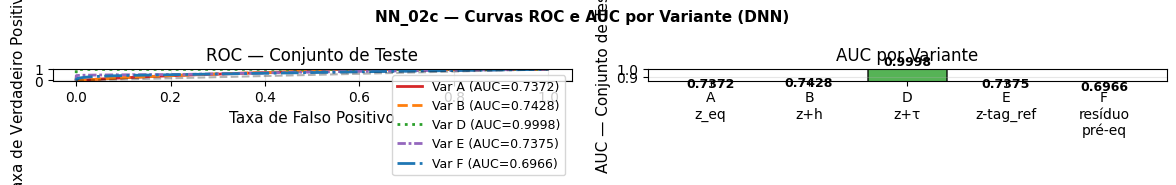

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2/NN_02c_ROC_AUC_DNN.png


In [ ]:
# ==============================================================================
# 6. VISUALIZAÇÕES: D3F PD vs SNR + ROC + AUC
# ==============================================================================

from sklearn.metrics import roc_auc_score, roc_curve

snr_arr    = np.array(SNR_BINS)
COLORS     = {'A': '#d62728', 'B': '#ff7f0e', 'F': '#1f77b4', 'D': '#2ca02c', 'E': '#9467bd'}
MARKERS    = {'A': 'o', 'B': '^', 'F': 's', 'D': 'D', 'E': 'P'}
LINESTYLES = {'A': '-', 'B': '--', 'F': '-.', 'D': ':', 'E': (0, (3, 1, 1, 1))}

# Gráfico 1: Probabilidade de detecção versus SNR sob framework D3F
fig1, ax1 = plt.subplots(figsize=(9, 5.5))

# Linha de referência: correlador clássico com limiar analítico
ax1.plot(snr_arr, [CLASSICAL_PD[s]/100 for s in SNR_BINS],
          'k-s', linewidth=2.2, markersize=7,
          label='Correlador clássico (empírico, D3F threshold)')
ax1.plot(snr_arr, [XIE_CLOSED_FORM_PD[s]/100 for s in SNR_BINS],
          color='dimgray', linestyle='--', marker='D', linewidth=2.0, markersize=6,
          label='Correlador clássico (fórmula fechada, Xie et al. 2021, Rayleigh-média)')

# Traços para cada variante
for var in ['A', 'B', 'D', 'E', 'F']:
    if var not in results_ablation: continue
    r  = results_ablation[var]
    pd = [r['pd_d3f'][s] for s in SNR_BINS]
    ax1.plot(snr_arr, pd,
             color=COLORS[var], ls=LINESTYLES[var], lw=2,
             marker=MARKERS[var], ms=7,
             label=f"Var {var}: {r['label']}")

ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax1.set_title('NN_02c — Ablação z_eq com DNN: $P_D$ vs SNR  (D3F, $\\alpha=0{,}01$, $L=1024$, Rayleigh)',
              fontsize=11, fontweight='bold')
ax1.set_xlim(-1, 31); ax1.set_ylim(-0.05, 1.05)
ax1.set_xticks(SNR_BINS)
ax1.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.3)
plt.tight_layout()
vis1 = visualizations_dir / 'NN_02c_D3F_PD_vs_SNR_DNN.png'
plt.savefig(str(vis1), dpi=150)
plt.show()
print(f"Figura salva → {vis1}")

# Tabela resumida em formato texto
print(f"\n{'Variante':<5}  {'Input':<28}  " +
      "  ".join(f"{s:>5}dB" for s in SNR_BINS))
print("-" * 90)
cl_vals = "  ".join(f"{CLASSICAL_PD[s]:>7.1f}" for s in SNR_BINS)
print(f"{'Clás':<5}  {'Correlador analítico':<28}  {cl_vals}")
for var in ['A', 'B', 'D', 'E', 'F']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    vals = "  ".join(f"{r['pd_d3f'][s]*100:>7.1f}" for s in SNR_BINS)
    print(f"{var:<5}  {r['label']:<28}  {vals}")
print("-" * 90)

# Gráfico 2: Curvas ROC e AUC por variante
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))
fig3.suptitle('NN_02c — Curvas ROC e AUC por Variante (DNN)', fontsize=11, fontweight='bold')

ax_roc = axes3[0]
for var in ['A', 'B', 'D', 'E', 'F']:
    if var not in results_ablation: continue
    r   = results_ablation[var]
    auc = roc_auc_score(lbl_test_arr, r['sc_test'])
    fpr, tpr, _ = roc_curve(lbl_test_arr, r['sc_test'])
    ax_roc.plot(fpr, tpr, color=COLORS[var], ls=LINESTYLES[var], lw=2,
                label=f"Var {var} (AUC={auc:.4f})")
    results_ablation[var]['auc_test'] = round(auc, 6)

ax_roc.plot([0,1],[0,1],'k--', alpha=0.3)
ax_roc.set_xlabel('Taxa de Falso Positivo', fontsize=11);
ax_roc.set_ylabel('Taxa de Verdadeiro Positivo ($P_D$)', fontsize=11)
ax_roc.set_title('ROC — Conjunto de Teste')
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# Gráfico de barras: AUC por variante
ax_auc = axes3[1]
aucs  = [results_ablation[v]['auc_test'] for v in ['A', 'B', 'D', 'E', 'F'] if v in results_ablation]
vlabs_map = {'A': 'A\nz_eq', 'B': 'B\nz+h', 'D': 'D\nz+τ', 'E': 'E\nz-tag_ref', 'F': 'F\nresíduo\npré-eq'}
vlabs = [vlabs_map[v] for v in ['A', 'B', 'D', 'E', 'F'] if v in results_ablation]
bars  = ax_auc.bar(vlabs, aucs,
                   color=[COLORS[v] for v in ['A', 'B', 'D', 'E', 'F'] if v in results_ablation],
                   alpha=0.8, edgecolor='black', lw=1.2)
for bar, auc in zip(bars, aucs):
    ax_auc.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_auc.set_ylabel('AUC — Conjunto de Teste', fontsize=11)
ax_auc.set_title('AUC por Variante')
ax_auc.set_ylim([0.85, 1.0])
ax_auc.grid(alpha=0.3, axis='y')

plt.tight_layout()
vis3 = visualizations_dir / 'NN_02c_ROC_AUC_DNN.png'
plt.savefig(str(vis3), dpi=150)
plt.show()
print(f"Figura salva → {vis3}")

In [ ]:
# 1. Confirmar se 'snr' armazenado é nominal (pré-fading) ou instantâneo (pós-fading)
print(snr_val_arr[:20])  # deveria ser um valor "de projeto", não |h|²·snr_nom

# 2. Checar a dispersão REAL de snr dentro do bin "0dB"
m0_check = (snr_val_arr >= -2.5) & (snr_val_arr < 2.5) & (lbl_val_arr == 0)
print("min/max/std do snr dentro do bin 0dB:", 
      snr_val_arr[m0_check].min(), snr_val_arr[m0_check].max(), snr_val_arr[m0_check].std())

# 3. Tamanho da amostra por bin (descartar problema de amostra pequena)
print("N amostras H0 no bin 0dB (val):", m0_check.sum())

[25.905914   5.593935  21.649405   3.9685879  3.4207351 14.613085
  6.791261   7.955682   3.8384185 26.006413   9.620452  29.628609
 13.3346    25.2439    17.18264   28.293783   1.8317604  2.3871918
  1.2949998 22.352028 ]
min/max/std do snr dentro do bin 0dB: 0.0019791839 2.4997535 0.7215942
N amostras H0 no bin 0dB (val): 1895


In [ ]:
# Comparar limiar/estatísticas empíricas vs. teóricas, no MESMO bin (0dB)
m0 = (snr_val_arr >= -2.5) & (snr_val_arr < 2.5) & (lbl_val_arr == 0)
mu_emp, sig_emp = tau_val_arr[m0].mean(), tau_val_arr[m0].std()
thr_emp = mu_emp + Q_INV_D3F * sig_emp

# Teórico, no MESMO gamma médio real do bin (não snr=0 exato)
gamma_medio_bin = 10**(snr_val_arr[m0].mean()/10)
L_eff = 1024 * (1/3)
sigma_teo = np.sqrt(L_eff / (2 * RHO_T**2 * gamma_medio_bin))  # sigma sob H0, modelo Xie
u0_teo, pd_teo = xie_closed_form_rayleigh(1024, RHO_T, snr_val_arr[m0].mean(), 0.01)

print(f"mu_empirico={mu_emp:.4f}  (teórico: 0.0)")
print(f"sigma_empirico={sig_emp:.4f}  sigma_teorico={sigma_teo:.4f}  razão={sig_emp/sigma_teo:.4f}")
print(f"thr_empirico={thr_emp:.4f}  thr_teorico(u0)={u0_teo:.4f}")

mu_empirico=31.9053  (teórico: 0.0)
sigma_empirico=44.3653  sigma_teorico=20.6064  razão=2.1530
thr_empirico=135.1144  thr_teorico(u0)=143.5143


In [ ]:
# ============================================================================= =
# 7. FOCO NA VARIANTE E
# ============================================================================= =
if 'E' in results_ablation:
    ranking_auc = sorted(
        ((var, results_ablation[var].get('auc_test', results_ablation[var]['best_val_auc'])) for var in results_ablation),
        key=lambda item: item[1],
        reverse=True
    )
    ranking_pd0 = sorted(
        ((var, results_ablation[var]['pd_d3f'].get(0, 0.0)) for var in results_ablation),
        key=lambda item: item[1],
        reverse=True
    )
    e_auc = results_ablation['E'].get('auc_test', results_ablation['E']['best_val_auc'])
    e_pd0 = results_ablation['E']['pd_d3f'].get(0, 0.0) * 100
    print('Resumo Variante E (DNN):')
    print(f"  AUC      : {e_auc:.6f}")
    print(f"  PD @ 0dB : {e_pd0:.1f}%")
    print(f"  Ranking por AUC : {ranking_auc}")
    print(f"  Ranking por PD@0dB : {ranking_pd0}")
else:
    print('Treine ou recupere a Variante E para gerar este resumo.')

Resumo Variante E (DNN):
  AUC      : 0.737540
  PD @ 0dB : 1.3%
  Ranking por AUC : [('D', 0.999826), ('B', 0.742805), ('E', 0.73754), ('A', 0.737176), ('F', 0.696593)]
  Ranking por PD@0dB : [('D', 0.9853479853479854), ('B', 0.027210884353741496), ('A', 0.013605442176870748), ('E', 0.012558869701726845), ('F', 0.0010465724751439038)]
